# 勇者傳說 — Overworld Hero V1 Generator (T4 GPU)

**專門針對勇者角色的 overworld 生成**，與戰鬥風格一致（參考 `CharacterParts.ts` HERO_APPEARANCE）。

玩家最常接觸的角色，城鎮與野外效果需與遊戲風格相符。

**V1 特點：**
- 僅生成 `char_hero`（勇者）
- Prompt 對齊 portrait_hero + 戰鬥勇者外觀（金冠、深紅披風、藍色鎧甲、金徽章）
- 4 candidates、5 retries，提高品質門檻
- 輸出覆蓋 `overworld_characters/char_hero.png`

**Output**: `overworld_characters/char_hero.png` (64×96 RGBA)

## 0. CLEANUP (Hero only)

僅刪除勇者相關的 progress 與輸出，不影響其他 overworld 角色。

In [1]:
import os
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')

deleted = 0
progress_path = OUTPUT_BASE / '_progress_owc_hero_v1.json'
if progress_path.exists():
    progress_path.unlink()
    print(f'  Deleted: {progress_path.name}')
    deleted += 1

hero_png = OUTPUT_BASE / 'overworld_characters' / 'char_hero.png'
if hero_png.exists():
    hero_png.unlink()
    print(f'  Deleted: overworld_characters/char_hero.png')
    deleted += 1

if deleted == 0:
    print('Nothing to clean up (first run).')
else:
    print(f'\nCleaned {deleted} items. Ready for hero generation.')

Mounted at /content/drive
  Deleted: overworld_characters/char_hero.png

Cleaned 1 items. Ready for hero generation.


## 1. Setup

In [2]:
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, time
from pathlib import Path

MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU! Generation will be very slow.')

print(f'Output: {OUTPUT_BASE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 67.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

## 2. Utilities

In [3]:
import numpy as np
from scipy import ndimage

class ProgressTracker:
    """Track completed items so we can resume after interruption."""
    def __init__(self, name, base_dir):
        self.path = Path(base_dir) / f'_progress_{name}.json'
        self.done = set()
        if self.path.exists():
            try:
                self.done = set(json.loads(self.path.read_text()))
            except Exception:
                pass

    def is_done(self, key):
        return key in self.done

    def mark_done(self, key):
        self.done.add(key)
        self.path.write_text(json.dumps(sorted(self.done)))

    def summary(self, total):
        return f'{len(self.done)}/{total} done'


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram(label=''):
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1024**3
        total = torch.cuda.get_device_properties(0)
        total_gb = (getattr(total, 'total_memory', None) or getattr(total, 'total_mem', 0)) / 1024**3
        print(f'VRAM {label}: {used:.1f} / {total_gb:.1f} GB')
    else:
        print(f'VRAM {label}: N/A (CPU)')


def largest_connected_component(rgba_img):
    """Extract the largest connected non-transparent region from RGBA image.
    Uses 8-connected labeling with dilation to bridge small gaps.
    Returns the cropped RGBA image of just the main figure."""
    arr = np.array(rgba_img)
    alpha = arr[:, :, 3]
    mask = alpha > 30  # threshold for non-transparent

    # Dilate slightly to bridge 1-2px gaps between parts (e.g. weapon and hand)
    struct = ndimage.generate_binary_structure(2, 2)  # 8-connected
    dilated = ndimage.binary_dilation(mask, struct, iterations=3)

    labeled, n_features = ndimage.label(dilated, structure=struct)
    if n_features <= 1:
        return rgba_img  # single component or empty

    # Find largest component
    sizes = ndimage.sum(mask, labeled, range(1, n_features + 1))
    largest_label = np.argmax(sizes) + 1

    # Create mask for largest component (use original non-dilated pixels)
    keep_mask = (labeled == largest_label) & mask

    # Zero out pixels not in largest component
    result = arr.copy()
    result[~keep_mask] = [0, 0, 0, 0]

    from PIL import Image
    return Image.fromarray(result)


def quality_score(rgba_img, target_w=64, target_h=96):
    """Score an RGBA image for quality as a character sprite.
    Returns (score, fill_ratio, height_ratio) where score = fill * height.
    fill_ratio: fraction of target area that has non-transparent pixels.
    height_ratio: fraction of target height that the figure occupies."""
    arr = np.array(rgba_img)
    alpha = arr[:, :, 3]
    mask = alpha > 30

    total_pixels = target_w * target_h
    filled_pixels = np.sum(mask)
    fill_ratio = filled_pixels / total_pixels

    # Height coverage: how much vertical space the figure uses
    rows_with_content = np.any(mask, axis=1)
    if not np.any(rows_with_content):
        return 0.0, 0.0, 0.0

    first_row = np.argmax(rows_with_content)
    last_row = len(rows_with_content) - np.argmax(rows_with_content[::-1]) - 1
    content_height = last_row - first_row + 1
    height_ratio = content_height / rgba_img.height

    score = fill_ratio * height_ratio
    return score, fill_ratio, height_ratio


# Quality thresholds
MIN_FILL_RATIO = 0.15
MIN_HEIGHT_RATIO = 0.50

print('Utilities ready (scipy LCC + quality gate)')

Utilities ready (scipy LCC + quality gate)


## 3. Prompt Data

**V3 changes:**
- Prompts are shorter (< 60 tokens each to stay within CLIP 77-token limit after prefix/suffix)
- No `style_prefix_xl` concatenation — style keywords baked into each prompt
- Negative prompt strengthened against multi-character and sprite-sheet generation

In [4]:
# Hero-only prompt aligned with battle style (HERO_APPEARANCE + portrait_hero)
NEGATIVE = 'blurry, text, watermark, signature, multiple characters, duplicate, group, sprite sheet, multiple views, multiple poses, turnaround, side view, profile, realistic photo, complex background, border, frame, grid'

HERO = [
    {'name': 'char_hero', 'prompt': 'pixel art, single chibi character, young prince swordsman hero, golden circlet, deep crimson cape, blue steel armor with gold shoulder pauldrons and chest emblem, sword, standing idle front view, determined expression, dark background'},
]

print(f'Hero to generate: {HERO[0]["name"]}')
print(f'Prompt: {HERO[0]["prompt"][:80]}...')

Hero to generate: char_hero
Prompt: pixel art, single chibi character, young prince swordsman hero, golden circlet, ...


## 4. Load SDXL Pipeline + LoRA

In [5]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

print_vram('before load')

MODEL_ID = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_ID = 'nerijs/pixel-art-xl'
LORA_WEIGHT = 0.8  # V3: lower from 0.9 to reduce over-pixelation artifacts

cached = MODELS_DIR / 'sdxl-base-fp16'
if cached.exists() and (cached / 'model_index.json').exists():
    print(f'Loading SDXL from cache: {cached}')
    pipe = StableDiffusionXLPipeline.from_pretrained(
        str(cached), torch_dtype=DTYPE, use_safetensors=True)
else:
    print(f'Downloading SDXL from HuggingFace...')
    pipe = StableDiffusionXLPipeline.from_pretrained(
        MODEL_ID, torch_dtype=DTYPE, use_safetensors=True, variant='fp16')
    if ON_COLAB:
        try:
            print(f'Caching to Drive: {cached}')
            pipe.save_pretrained(str(cached))
        except Exception as e:
            print(f'[warn] Drive cache failed: {e}')

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True)

print(f'Loading LoRA: {LORA_ID} (weight={LORA_WEIGHT})')
pipe.load_lora_weights(LORA_ID)
pipe.fuse_lora(lora_scale=LORA_WEIGHT)

pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()

print_vram('after load')
print('Pipeline ready!')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


VRAM before load: 0.0 / 14.6 GB
Loading SDXL from cache: /content/drive/MyDrive/ai-rpg-game/models/sdxl-base-fp16


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading LoRA: nerijs/pixel-art-xl (weight=0.8)


pixel-art-xl.safetensors:   0%|          | 0.00/171M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


VRAM after load: 6.7 / 14.6 GB
Pipeline ready!


In [6]:
from PIL import Image

TARGET_W = 64
TARGET_H = 96

_rembg_session = None

def remove_background(image):
    """Remove background using rembg (u2net). Returns RGBA."""
    global _rembg_session
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(image, session=_rembg_session)
    except Exception as e:
        print(f'[warn] rembg failed: {e}')
        return image.convert('RGBA')


def postprocess(image):
    """Full pipeline: rembg → LCC → crop → resize → quality check.
    Returns (final_image, score, fill_ratio, height_ratio)."""
    # 1. Background removal
    rgba = remove_background(image)

    # 2. Largest connected component (remove floating artifacts)
    rgba = largest_connected_component(rgba)

    # 3. Crop to bounding box
    bbox = rgba.getbbox()
    if bbox:
        rgba = rgba.crop(bbox)

    # 4. Fit into 64x96, maintaining aspect ratio, bottom-aligned
    w, h = rgba.size
    if w == 0 or h == 0:
        canvas = Image.new('RGBA', (TARGET_W, TARGET_H), (0, 0, 0, 0))
        return canvas, 0.0, 0.0, 0.0

    scale = min(TARGET_W / w, TARGET_H / h)
    nw, nh = max(1, int(w * scale)), max(1, int(h * scale))
    rgba = rgba.resize((nw, nh), Image.NEAREST)

    # Center horizontally, bottom-align vertically (feet at bottom edge)
    canvas = Image.new('RGBA', (TARGET_W, TARGET_H), (0, 0, 0, 0))
    paste_x = (TARGET_W - nw) // 2
    paste_y = TARGET_H - nh
    canvas.paste(rgba, (paste_x, paste_y), rgba)

    # 5. Quality score
    score, fill_r, height_r = quality_score(canvas, TARGET_W, TARGET_H)
    return canvas, score, fill_r, height_r


NUM_CANDIDATES = 4
MAX_RETRIES = 5

def generate_one(entry, out_dir, tracker, steps=30, guidance=9.5):
    """Generate character with quality gate and candidate selection."""
    name = entry['name']
    prompt = entry['prompt']
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name) and out_path.exists():
        print(f'  [skip] {name}')
        return False

    print(f'  [gen] {name} ({steps} steps, guidance={guidance}, {NUM_CANDIDATES} candidates)')
    t0 = time.time()

    best_img = None
    best_score = -1
    attempt = 0

    while attempt < MAX_RETRIES:
        candidates = []
        for c in range(NUM_CANDIDATES):
            seed = int(time.time() * 1000) % (2**32) + attempt * 100 + c
            gen = torch.Generator(device=DEVICE).manual_seed(seed)

            result = pipe(
                prompt=prompt, negative_prompt=NEGATIVE,
                width=512, height=768,
                num_inference_steps=steps, guidance_scale=guidance,
                generator=gen,
            )
            raw = result.images[0]
            img, score, fill_r, height_r = postprocess(raw)
            candidates.append((img, score, fill_r, height_r, seed))
            print(f'        candidate {c}: score={score:.3f} fill={fill_r:.2f} height={height_r:.2f} seed={seed}')

        # Pick best candidate
        candidates.sort(key=lambda x: x[1], reverse=True)
        top = candidates[0]

        # Quality gate
        if top[2] >= MIN_FILL_RATIO and top[3] >= MIN_HEIGHT_RATIO:
            best_img = top[0]
            best_score = top[1]
            print(f'        PASS: score={best_score:.3f}')
            break
        else:
            attempt += 1
            print(f'        FAIL quality gate (fill={top[2]:.2f}<{MIN_FILL_RATIO} or height={top[3]:.2f}<{MIN_HEIGHT_RATIO}), retry {attempt}/{MAX_RETRIES}')
            # Keep best so far in case all retries fail
            if top[1] > best_score:
                best_img = top[0]
                best_score = top[1]
            free_vram()

    if best_img is None:
        print(f'        WARNING: all retries failed for {name}, using best attempt')
        best_img = candidates[0][0] if candidates else Image.new('RGBA', (TARGET_W, TARGET_H), (0, 0, 0, 0))

    best_img.save(str(out_path), 'PNG')
    kb = out_path.stat().st_size / 1024
    print(f'        saved: {name}.png ({kb:.0f} KB, {time.time()-t0:.1f}s)')
    tracker.mark_done(name)
    free_vram()
    return True

print('Generation pipeline ready (4 candidates, 5 retries, quality gate)')

Generation pipeline ready (4 candidates, 5 retries, quality gate)


## 6. Test: Generate 1 Character

Quick visual check before batch generation.

Prompt: pixel art, single chibi character, young prince swordsman hero, golden circlet, deep crimson cape, blue steel armor with gold shoulder pauldrons and chest emblem, sword, standing idle front view, determined expression, dark background
Negative: blurry, text, watermark, signature, multiple characters, duplicate, group, sprit...


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


Raw 512x768:


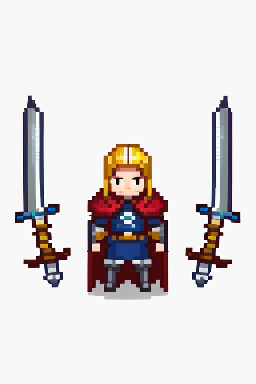

  0%|                                               | 0.00/176M [00:00<?, ?B/s]


Processed 64x96 (shown at 6x):
Quality: score=0.653, fill=0.65, height=1.00
Gate: PASS


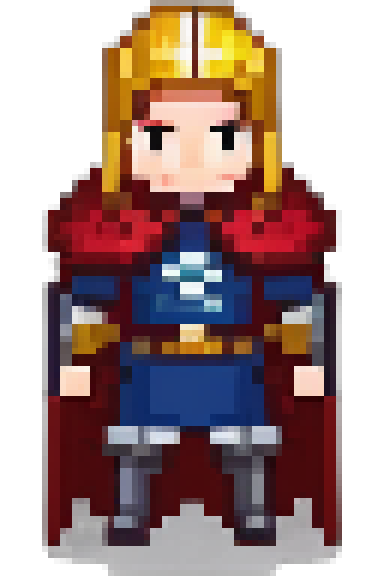

In [7]:
from IPython.display import display

test_entry = HERO[0]  # hero
print(f'Prompt: {test_entry["prompt"]}')
print(f'Negative: {NEGATIVE[:80]}...')

seed = 42
gen = torch.Generator(device=DEVICE).manual_seed(seed)
result = pipe(prompt=test_entry['prompt'], negative_prompt=NEGATIVE,
              width=512, height=768, num_inference_steps=30, guidance_scale=9.5,
              generator=gen)
print('Raw 512x768:')
display(result.images[0].resize((256, 384), Image.NEAREST))

processed, score, fill_r, height_r = postprocess(result.images[0])
zoomed = processed.resize((TARGET_W * 6, TARGET_H * 6), Image.NEAREST)
print(f'\nProcessed {TARGET_W}x{TARGET_H} (shown at 6x):')
print(f'Quality: score={score:.3f}, fill={fill_r:.2f}, height={height_r:.2f}')
gate = 'PASS' if fill_r >= MIN_FILL_RATIO and height_r >= MIN_HEIGHT_RATIO else 'FAIL'
print(f'Gate: {gate}')
display(zoomed)
free_vram()

## 7. Generate Hero

~1–2 min (4 candidates × 30 steps × up to 5 retries)

In [8]:
out_dir = OUTPUT_BASE / 'overworld_characters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('owc_hero_v1', OUTPUT_BASE)
remaining = sum(1 for e in HERO if not tracker.is_done(e['name']))
print(f'\nHero: {len(HERO)} to generate, {remaining} remaining')

for i, entry in enumerate(HERO):
    print(f'\n[{i+1}/{len(HERO)}] {tracker.summary(len(HERO))}')
    generate_one(entry, out_dir, tracker, steps=30, guidance=9.5)

print(f'\nHero generation complete!')


Hero: 1 to generate, 1 remaining

[1/1] 0/1 done
  [gen] char_hero (30 steps, guidance=9.5, 4 candidates)


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


        candidate 0: score=0.161 fill=0.33 height=0.49 seed=3512142001


  0%|          | 0/30 [00:00<?, ?it/s]

        candidate 1: score=0.604 fill=0.60 height=1.00 seed=3512155103


  0%|          | 0/30 [00:00<?, ?it/s]

        candidate 2: score=0.391 fill=0.45 height=0.88 seed=3512168480


  0%|          | 0/30 [00:00<?, ?it/s]

        candidate 3: score=0.544 fill=0.58 height=0.94 seed=3512182271
        PASS: score=0.604
        saved: char_hero.png (9 KB, 60.7s)

Hero generation complete!


## 8. Export + Download

Zip `outputs/` and download. Import: `bash scripts/import_colab_assets.sh ~/Downloads/overworld_hero_v1_output`

In [9]:
import shutil

zip_path = '/content/overworld_hero_v1_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'Zip: {os.path.getsize(zip_path + ".zip") / 1024 / 1024:.1f} MB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')

Zip: 43.0 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>